<a href="https://colab.research.google.com/github/yuwaniyash/Airbnb-DataScience-Project/blob/main/NLP_notebook/NLP_sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 7.1 — Sentiment Analysis on Reviews

Correlates guest review sentiment against `review_scores_rating` from `listings_master`.

The reviews are written in multiple languages, including French, German, Italian, and English, since the dataset is from Vaud, Switzerland. Because of this, using an English-only sentiment analysis tool such as VADER would incorrectly score a large portion of the reviews. Therefore, the nlptown/bert-base-multilingual-uncased-sentiment model was used, as it is a multilingual transformer that has been fine-tuned on 1–5 star review ratings and is considered one of the standard models for multilingual sentiment analysis in this type of scenario.


In [1]:
!pip install sqlalchemy psycopg2-binary --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 63.2 MB/s eta 0:00:00


# Connect to Supabase

In [2]:
from google.colab import userdata
from sqlalchemy import create_engine, text
import pandas as pd

SUPABASE_URL = userdata.get('SUPABASE_DATABASE_URL')
engine = create_engine(SUPABASE_URL)

with engine.connect() as conn:
    conn.execute(text("SELECT 1"))
print("Connected to Supabase")

Connected to Supabase


# Load Reviews(Joined with dim_date)

In [3]:
query = """
    SELECT rt.review_key AS review_id,
           rt.listing_key,
           d.full_date AS review_date,
           rt.comments
    FROM reviews_text rt
    JOIN dim_date d ON rt.date_id = d.date_id
    WHERE rt.comments IS NOT NULL
"""

reviews_df = pd.read_sql(query, engine)
print(reviews_df.shape)
reviews_df.head()

(134591, 4)


,review_id,listing_key,review_date,comments
0,1852654,7381,2012-07-31,"A cosy and stylish chalet flat, in an exceptio..."
1,17757770,7381,2014-08-17,Super semaine au chalet de Paula. Il est super...
2,47459125,7381,2015-09-19,Paula was very welcoming. She responded immed...
3,110403296,7381,2016-10-26,Paula gave us a very accurate instructions on ...
4,184285103,7381,2017-08-19,Appartement dans un ancien chalet authentique ...


# Clean Review Text

In [4]:
import re, html

def clean_review_text(txt):
    if pd.isna(txt):
        return ""
    txt = html.unescape(txt)
    txt = re.sub(r"<[^>]+>", " ", txt)
    txt = re.sub(r"\s+", " ", txt).strip()
    return txt

reviews_df["comments_clean"] = reviews_df["comments"].apply(clean_review_text)
reviews_df = reviews_df[reviews_df["comments_clean"].str.len() > 0].reset_index(drop=True)
print(f"{len(reviews_df)} reviews with usable text")

134591 reviews with usable text


# Load the Sentiment Model

In [5]:
from transformers import pipeline

sentiment_model = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    truncation=True,
    max_length=512,
    device=0  # uses the T4 GPU
)

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

# Run Sentiment Inference in Batches

In [6]:
from tqdm.auto import tqdm

BATCH_SIZE = 64  # can go higher than CPU thanks to GPU
results = []
texts = reviews_df["comments_clean"].tolist()

for i in tqdm(range(0, len(texts), BATCH_SIZE)):
    batch = texts[i:i + BATCH_SIZE]
    out = sentiment_model(batch)
    results.extend(out)

reviews_df["sentiment_stars"] = [int(r["label"][0]) for r in results]
reviews_df["sentiment_confidence"] = [r["score"] for r in results]
reviews_df["sentiment_score"] = (reviews_df["sentiment_stars"] - 3) / 2
reviews_df[["comments_clean", "sentiment_stars", "sentiment_score", "sentiment_confidence"]].head()

  0%|          | 0/2103 [00:00<?, ?it/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,comments_clean,sentiment_stars,sentiment_score,sentiment_confidence
0,"A cosy and stylish chalet flat, in an exceptio...",5,1.0,0.881748
1,Super semaine au chalet de Paula. Il est super...,5,1.0,0.698828
2,Paula was very welcoming. She responded immedi...,4,0.5,0.469560
3,Paula gave us a very accurate instructions on ...,5,1.0,0.672694
4,Appartement dans un ancien chalet authentique ...,5,1.0,0.530700


# Correlate with review_scores_rating

In [7]:
listings_scores = pd.read_sql(
    "SELECT id AS listing_key, review_scores_rating FROM listings_master",
    engine
)
merged = reviews_df.merge(listings_scores, on="listing_key", how="left")

from scipy.stats import pearsonr
valid = merged.dropna(subset=["sentiment_score", "review_scores_rating"])
r, p = pearsonr(valid["sentiment_score"], valid["review_scores_rating"])
print(f"Pearson r = {r:.3f}, p = {p:.4f}, n = {len(valid)}")

Pearson r = 0.250, p = 0.0000, n = 134591


# Plots

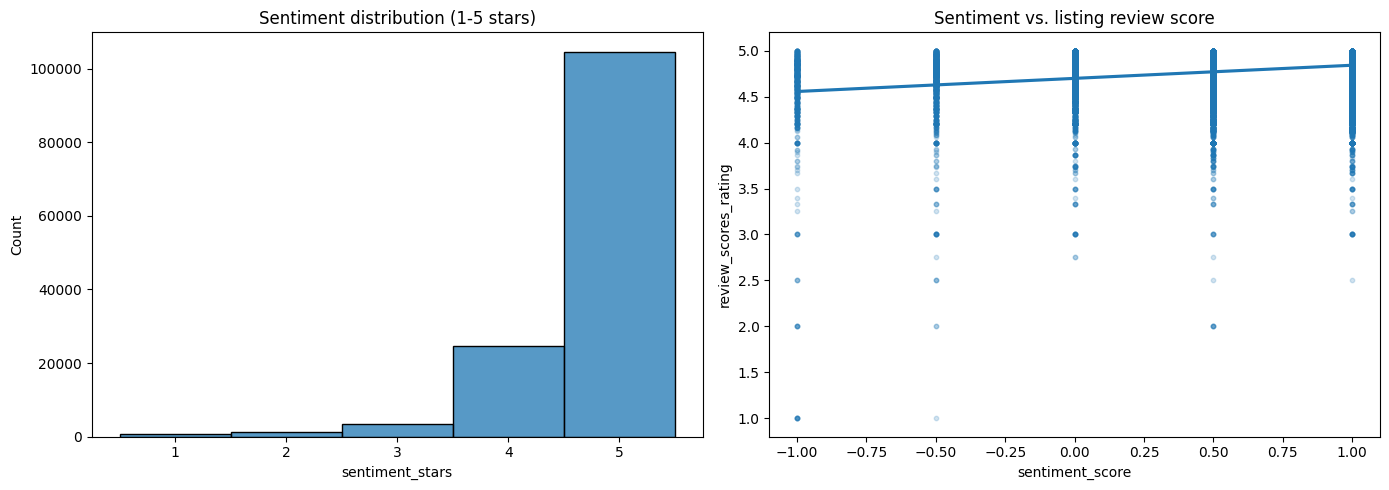

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(reviews_df["sentiment_stars"], bins=5, discrete=True, ax=axes[0])
axes[0].set_title("Sentiment distribution (1-5 stars)")

sns.regplot(data=valid, x="sentiment_score", y="review_scores_rating",
            scatter_kws={"alpha": 0.2, "s": 10}, ax=axes[1])
axes[1].set_title("Sentiment vs. listing review score")

plt.tight_layout()
plt.show()

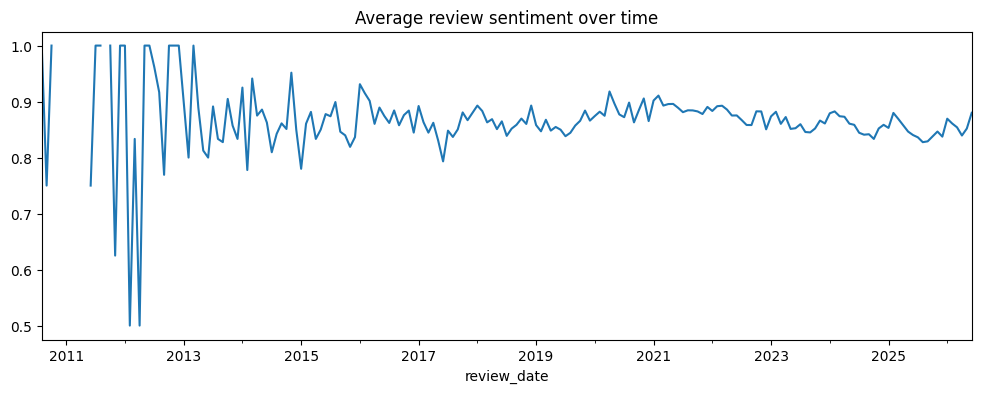

In [9]:
merged["review_date"] = pd.to_datetime(merged["review_date"])
monthly = merged.set_index("review_date").resample("ME")["sentiment_score"].mean()

plt.figure(figsize=(12, 4))
monthly.plot()
plt.title("Average review sentiment over time")
plt.show()

**Writing results back to supabase**

In [10]:
output_df = reviews_df[[
    "review_id", "listing_key", "review_date",
    "sentiment_stars", "sentiment_score", "sentiment_confidence"
]]

output_df.to_sql("review_sentiment", engine, if_exists="replace", index=False)
print(f"Wrote {len(output_df)} rows to review_sentiment table in Supabase")

Wrote 134591 rows to review_sentiment table in Supabase
